# The composition trap: when normalization invents a difference

**A reproducible, self-contained demonstration.**

This notebook recreates a real problem I ran into during an RNA-seq analysis: a standard
normalization step made a set of features look clearly different between two groups when
they were, in truth, identical. The difference was an artifact of *library composition*,
not biology.

**The data here is fully synthetic.** I simulate it from a known ground truth so you can
see the artifact appear and then disappear. Nothing in this notebook comes from the
original study; the point is the method and the lesson, both of which transfer to any
setting where you normalize by a total (counts-per-million, percentages, rates, per-capita
anything).

**The setup.** Two groups, several samples each. Four kinds of features:

| label | ground truth | what should happen |
|---|---|---|
| `true_signal` | genuinely ~2x higher in group A | detected by every correct method |
| `true_null` | genuinely identical between groups | detected by nothing (this is the trap) |
| `background` | genuinely identical, the bulk of features | flat everywhere |
| `ncRNA_high` | a few features, hugely inflated in group B | drives the composition difference |

The question a naive analyst asks: *which features differ between A and B?* Watch what the
answer depends on.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})
rng = np.random.default_rng(7)

# palette
C = {"A": "#3b6ea5", "B": "#c0603a",
     "true_signal": "#2a6f4e", "true_null": "#c0603a",
     "background": "#9aa0a6", "ncRNA_high": "#8a6bbf"}

## 1. Simulate from a known ground truth

I define *absolute* expression per feature for each group, then simulate sequencing.
The key realism: a sequencer returns a fixed-size sample of *relative* abundances, not
absolute counts. So if a few features hog the library in one group, everything else in
that group is under-sampled, even when its true expression is unchanged. That single fact
is the whole artifact.


In [2]:
n_per_group = 6
n_signal, n_null, n_bg, n_nc = 25, 25, 450, 12

def base(n, loc=6.0, scale=0.9):
    # lognormal spread of baseline expression levels
    return rng.lognormal(mean=loc, sigma=scale, size=n)

# TRUE absolute expression per feature, per group (arbitrary units)
signal_A  = base(n_signal); signal_B  = signal_A / 2.0     # truly 2x higher in A
null_A    = base(n_null);   null_B    = null_A.copy()      # truly EQUAL
bg_A      = base(n_bg);     bg_B      = bg_A.copy()         # truly equal (the bulk)
nc_A      = base(n_nc, loc=7.95); nc_B = nc_A * 3.6         # noncoding, inflated in B

levels_A = np.concatenate([signal_A, null_A, bg_A, nc_A])
levels_B = np.concatenate([signal_B, null_B, bg_B, nc_B])

category = np.array(["true_signal"]*n_signal + ["true_null"]*n_null +
                    ["background"]*n_bg + ["ncRNA_high"]*n_nc)
feature_ids = [f"feat_{i:04d}" for i in range(len(category))]

def sequence(levels, n_samples, lib_mean=2.0e7, bio_cv=0.15):
    # Simulate n_samples libraries: add biological noise, then multinomial sampling
    # of a fixed-ish library size according to RELATIVE abundance.
    out = np.zeros((len(levels), n_samples), dtype=np.int64)
    shape = 1.0 / bio_cv**2
    for s in range(n_samples):
        true = rng.gamma(shape, levels / shape)      # per-sample biological variation
        p = true / true.sum()                        # relative abundance
        lib = int(rng.normal(lib_mean, lib_mean*0.08))
        out[:, s] = rng.multinomial(lib, p)          # sequencing = multinomial draw
    return out

counts = np.hstack([sequence(levels_A, n_per_group), sequence(levels_B, n_per_group)])
samples = [f"A{i+1}" for i in range(n_per_group)] + [f"B{i+1}" for i in range(n_per_group)]
group = np.array(["A"]*n_per_group + ["B"]*n_per_group)
counts_df = pd.DataFrame(counts, index=feature_ids, columns=samples)
counts_df.iloc[:3].join(pd.Series(category, index=feature_ids, name="truth").iloc[:3])

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,B5,B6,truth
feat_0000,20823,20125,24513,32328,31904,24744,13743,14362,13328,10504,11879,11779,true_signal
feat_0001,32127,35322,35602,31499,36947,27397,13006,14482,14493,13596,13192,17151,true_signal
feat_0002,25152,22883,19775,18884,21173,20275,6898,6583,7405,8258,7189,8419,true_signal


## 2. Audit the composition first

Before normalizing anything, look at what the libraries are *made of*. If the mix differs
between groups, total-count normalization is already on thin ice.


    ncRNA_fraction  top5_share
A1           0.126       0.101
A2           0.122       0.096
A3           0.121       0.098
A4           0.120       0.090
A5           0.116       0.090
A6           0.121       0.093
B1           0.293       0.199
B2           0.325       0.232
B3           0.315       0.230
B4           0.331       0.224
B5           0.335       0.242
B6           0.337       0.250

mean ncRNA fraction   A: 12.1%   B: 32.2%


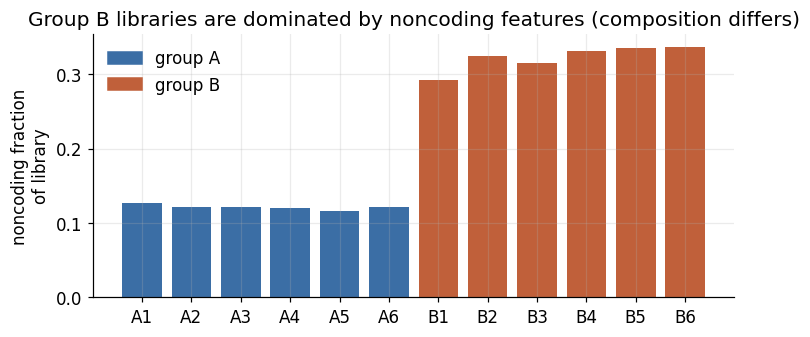

In [3]:
nc_mask = category == "ncRNA_high"
nc_frac = counts[nc_mask].sum(0) / counts.sum(0)
top5 = np.sort(counts, axis=0)[-5:].sum(0) / counts.sum(0)

summary = pd.DataFrame({"ncRNA_fraction": nc_frac, "top5_share": top5}, index=samples)
print(summary.round(3))
print(f"\nmean ncRNA fraction   A: {nc_frac[group=='A'].mean():.1%}   B: {nc_frac[group=='B'].mean():.1%}")

fig, ax = plt.subplots(figsize=(7, 3.2))
colors = [C[g] for g in group]
ax.bar(samples, nc_frac, color=colors)
ax.set_ylabel("noncoding fraction\nof library")
ax.set_title("Group B libraries are dominated by noncoding features (composition differs)")
handles = [plt.Rectangle((0,0),1,1,color=C[g]) for g in ["A","B"]]
ax.legend(handles, ["group A","group B"], frameon=False)
plt.tight_layout(); plt.show()

The two groups are not made of the same stuff. Roughly a third of group B's reads are
noncoding features that have nothing to do with the question, versus about an eighth in
group A. Total-count normalization divides every feature by that group-specific total.
Hold that thought.

## 3. Three normalizations

- **CPM** divides by the raw library total. Fast, ubiquitous, and blind to composition.
- **Median-of-ratios** (the DESeq2 idea) assumes most features do not change and centers
  each sample on the median feature-wise ratio to a pseudo-reference.
- **TMM** (the edgeR idea) does the same job via a trimmed, variance-weighted mean of
  log-ratios.

The last two are *composition-aware*: they look for the stable bulk of features and refuse
to let a handful of dominant ones set the scale.


In [4]:
def cpm(m):
    # Counts per million: scale each sample by its raw total. Composition-blind.
    return m / m.sum(0) * 1e6

def median_of_ratios(m):
    # DESeq2-style size factor = median ratio of each sample to the per-feature
    # geometric mean, over features expressed in every sample.
    with np.errstate(divide="ignore"):
        geo = np.exp(np.mean(np.log(np.where(m > 0, m, np.nan)), axis=1))
    keep = np.all(m > 0, axis=1)
    ratios = m[keep].astype(float) / geo[keep][:, None]
    sf = np.median(ratios, axis=0)
    return m / sf * 1e6 / (1e6 / np.exp(np.mean(np.log(m.sum(0)))))  # scale for readability

def tmm(m, logratio_trim=0.3, sum_trim=0.05):
    # edgeR-style trimmed mean of M-values. Reference = sample whose upper quartile
    # is closest to the average upper quartile.
    N = m.sum(0).astype(float)
    uq = np.array([np.percentile(m[:, j][m[:, j] > 0], 75) for j in range(m.shape[1])])
    ref = int(np.argmin(np.abs(uq - uq.mean())))
    r, Nr = m[:, ref].astype(float), N[ref]
    factors = np.ones(m.shape[1])
    for k in range(m.shape[1]):
        o, Nk = m[:, k].astype(float), N[k]
        mask = (o > 0) & (r > 0)
        oo, rr = o[mask], r[mask]
        M = np.log2((oo/Nk) / (rr/Nr))                 # log fold change vs reference
        A = 0.5*np.log2((oo/Nk) * (rr/Nr))             # mean abundance
        w = (Nk-oo)/(Nk*oo) + (Nr-rr)/(Nr*rr)          # delta-method weights
        keep = ((M >= np.quantile(M, logratio_trim)) & (M <= np.quantile(M, 1-logratio_trim)) &
                (A >= np.quantile(A, sum_trim)) & (A <= np.quantile(A, 1-sum_trim)))
        factors[k] = 2 ** (np.sum(w[keep]*M[keep]) / np.sum(w[keep])) if keep.any() else 1.0
    factors /= np.exp(np.mean(np.log(factors)))        # center factors at geomean 1
    return m / (N * factors) * 1e6

normalized = {"CPM": cpm(counts),
              "median-of-ratios": median_of_ratios(counts),
              "TMM": tmm(counts)}
print("normalization methods ready:", list(normalized))

normalization methods ready: ['CPM', 'median-of-ratios', 'TMM']


## 4. Ask the naive question under each method

For every feature, compute the log2 fold change (group B vs A) and a Welch t-test on
log-expression. Then summarize by ground-truth category. Remember: `true_null` and
`background` features are *identical* between groups. A correct method should report no
difference for them.


In [5]:
def differential(norm):
    a = np.log2(norm[:, group == "A"] + 1)
    b = np.log2(norm[:, group == "B"] + 1)
    lfc = b.mean(1) - a.mean(1)                         # log2 fold change, B vs A
    _, p = stats.ttest_ind(b, a, axis=1, equal_var=False)
    return lfc, p

rows = []
for name, norm in normalized.items():
    lfc, p = differential(norm)
    for cat in ["true_signal", "true_null", "background", "ncRNA_high"]:
        m = category == cat
        rows.append({"method": name, "category": cat,
                     "mean_log2FC": lfc[m].mean(),
                     "pct_significant": (p[m] < 0.05).mean()})
table = pd.DataFrame(rows)
pivot_fc  = table.pivot(index="category", columns="method", values="mean_log2FC")[list(normalized)]
pivot_sig = table.pivot(index="category", columns="method", values="pct_significant")[list(normalized)]

print("Mean log2 fold change (B vs A) by category:")
print(pivot_fc.round(2).loc[["true_signal","true_null","background","ncRNA_high"]])
print("\nFraction of features called significant (p < 0.05):")
print(pivot_sig.round(2).loc[["true_signal","true_null","background","ncRNA_high"]])

Mean log2 fold change (B vs A) by category:
method        CPM  median-of-ratios   TMM
category                                 
true_signal -1.34             -0.98 -0.99
true_null   -0.36              0.00 -0.00
background  -0.35              0.02  0.01
ncRNA_high   1.44              1.81  1.80

Fraction of features called significant (p < 0.05):
method        CPM  median-of-ratios   TMM
category                                 
true_signal  1.00              1.00  1.00
true_null    0.76              0.00  0.00
background   0.69              0.06  0.06
ncRNA_high   1.00              1.00  1.00


Read the `true_null` row. Under CPM it shows a fold change and a high false-positive rate.
Under both composition-aware methods it collapses to ~zero. The `true_signal` row survives
everywhere. That is the entire story in two tables; the plots below just make it obvious.


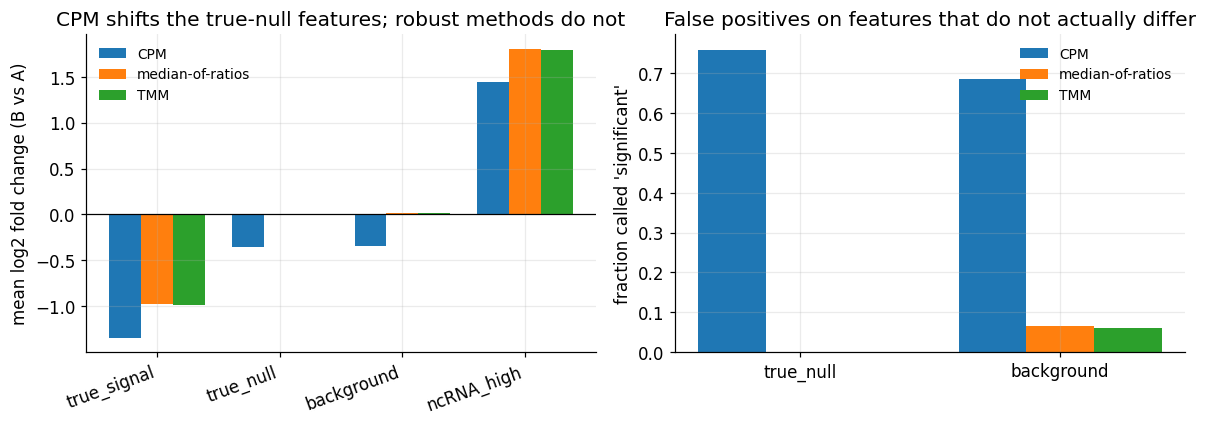

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# left: mean log2FC by category, grouped by method
cats = ["true_signal", "true_null", "background", "ncRNA_high"]
x = np.arange(len(cats)); w = 0.26
for i, name in enumerate(normalized):
    axes[0].bar(x + (i-1)*w, pivot_fc.loc[cats, name], w, label=name)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(cats, rotation=20, ha="right")
axes[0].set_ylabel("mean log2 fold change (B vs A)")
axes[0].set_title("CPM shifts the true-null features; robust methods do not")
axes[0].legend(frameon=False, fontsize=9)

# right: false-positive rate on the truly-identical features
null_bg = ["true_null", "background"]
fp = pivot_sig.loc[null_bg]
xx = np.arange(len(null_bg))
for i, name in enumerate(normalized):
    axes[1].bar(xx + (i-1)*w, fp[name], w, label=name)
axes[1].set_xticks(xx); axes[1].set_xticklabels(null_bg)
axes[1].set_ylabel("fraction called 'significant'")
axes[1].set_title("False positives on features that do not actually differ")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Why it happens, in one line

CPM divides by the raw total. Group B spends about a third of its total on noncoding
features, so *everything else* in group B is divided by a bigger number and looks lower,
whether or not it actually changed. The composition-aware methods find the large stable
bulk of features, notice it is flat, and rescale so the bulk lines up. Only the genuinely
2x `true_signal` features are left standing.

## 6. The transferable lesson

Normalization is a modeling assumption, not a formatting step. Any time you divide by a
total, you are trusting that the total means the same thing across your groups. When a
group-specific chunk of that total is unrelated to your question, you get differences that
are real in the arithmetic and false in the world.

The cheap insurance costs about ten lines of code: compute your result under more than one
reasonable normalization and only trust what survives all of them. Here, four of the
categories agreed across methods and one did not, and the one that did not was the artifact.
